### This notebook extract newly generated molecules after the DORAnet run: 

In [1]:
import os
import io
import json
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict, deque
from io import BytesIO
from IPython.display import display

from rdkit import Chem, DataStructs, RDLogger
from rdkit.Chem import AllChem, Descriptors, Draw, QED, rdMolDescriptors
from rdkit.Chem.Draw import rdMolDraw2D
from rdkit.SimDivFilters.rdSimDivPickers import MaxMinPicker

from PIL import Image, ImageDraw, ImageFont

RDLogger.DisableLog('rdApp.*')

In [2]:
from DORA_XGB import DORA_XGB
by_desc_MW_model = DORA_XGB.feasibility_classifier(cofactor_positioning = 'by_descending_MW')
by_asc_MW_model = DORA_XGB.feasibility_classifier(cofactor_positioning = 'by_ascending_MW')
add_concat_model = DORA_XGB.feasibility_classifier(cofactor_positioning = 'add_concat')
add_subtract_model = DORA_XGB.feasibility_classifier(cofactor_positioning = 'add_subtract')

/users/sghosh6/.conda/envs/doranet_env/lib/python3.10/site-packages/xgboost/compat.py:105: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [3]:
fileNamePrefix = "InosineOnly_gen3"

In [4]:
def canonSmiles(smi):
    mol = Chem.MolFromSmiles(str(smi))
    return Chem.MolToSmiles(mol) if mol else str(smi)

### Discover All Starter Directories

In [5]:
doranetOutputDir = "doranet_output"
doranet_generations = 3

helpersToExclude = {
    'O', 'O=O', '[H][H]', 'O=C=O', 'C=O', '[C-]#[O+]', 'Br', '[Br][Br]',
    'CO', 'C=C', 'O=S(O)O', 'N', 'O=S(=O)(O)O', 'O=NO', 'N#N',
    'O=[N+]([O-])O', 'NO', 'C#N', 'S', 'O=S=O', 'N#CO', '[H+]', 'OO',
    'Cl', 'I', 'O=C(O)O', 'O=P(O)(O)O', 'O=P(O)(O)OP(=O)(O)O', 'C',
    'CC', 'CC=O', 'CC(=O)O', 'CCC(=O)O'
}

print(f"Output directory: {doranetOutputDir}")
print(f"Number of helpers to exclude: {len(helpersToExclude)}")

Output directory: doranet_output
Number of helpers to exclude: 33


In [6]:
# Automatically find all *_molecules.csv files in the current working directory
currentDir = os.getcwd()

allMoleculesCsvFiles = sorted(glob.glob(os.path.join(currentDir, "*_molecules.csv")))

print(f"Found {len(allMoleculesCsvFiles)} molecules CSV files in current directory")

# Parse discovered CSV files
discoveredCsvFiles = []

for csvPath in allMoleculesCsvFiles:
    fileName = os.path.basename(csvPath)
    dirName = fileName.replace('_molecules.csv', '')
    
    try:
        starterNum = int(dirName.replace('starter_', ''))
    except ValueError:
        starterNum = -1  # For non-standard naming

    discoveredCsvFiles.append({
        'dirName': dirName,
        'dirPath': currentDir,
        'csvPath': csvPath,
        'starterNum': starterNum
    })

# Sort by starter number
discoveredCsvFiles.sort(key=lambda x: x['starterNum'])

print(f"Found {len(discoveredCsvFiles)} CSV files containing DORAnet generated molecules")

Found 1 molecules CSV files in current directory
Found 1 CSV files containing DORAnet generated molecules


### Extract the `DORAnet` starter molecule

Starter 01: C1=NC2=C(C(=O)N1)N=CN2[C@H]3[C@@H]([C@@H]([C@H](O3)CO)O)O


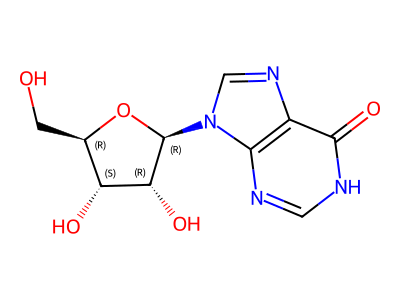

In [22]:
from IPython.display import display, SVG

invalidSmiles = []

for i, smi in enumerate(user_starters, 1):
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        invalidSmiles.append(smi)
        continue

    for fmt, drawClass, ext in [
        ("svg", rdMolDraw2D.MolDraw2DSVG, "svg"),
        ("png", rdMolDraw2D.MolDraw2DCairo, "png"),
    ]:
        drawer = drawClass(400, 300)
        drawer.drawOptions().addStereoAnnotation = True
        drawer.DrawMolecule(mol)
        drawer.FinishDrawing()

        savePath = os.path.join(f"{fileNamePrefix}_starter_{i:02d}.{ext}")
        if fmt == "svg":
            with open(savePath, "w") as f:
                f.write(drawer.GetDrawingText())
        else:
            with open(savePath, "wb") as f:
                f.write(drawer.GetDrawingText())

    print(f"Starter {i:02d}: {smi}")
    display(SVG(drawer.GetDrawingText() if fmt == "svg" else
                open(os.path.join(f"{fileNamePrefix}_starter_{i:02d}.svg")).read()))

if invalidSmiles:
    print(f"\nCould not parse {len(invalidSmiles)} SMILES:")
    for smi in invalidSmiles:
        print(f"  {smi}")

### Read `reaction_strings` from the `DORAnet` generated `json` file

In [8]:
jsonFile = f"{fileNamePrefix}_network_pretreated.json"

with open(jsonFile, "r", encoding="utf-8") as f:
    reactionList = json.load(f)

def splitMoleculeString(moleculeString):
    if pd.isna(moleculeString) if hasattr(pd, 'isna') else moleculeString is None:
        return []
    return [mol for mol in str(moleculeString).split(".") if mol]

reactionRecords = []

for rxn in reactionList:
    parts = str(rxn).split(">")
    if len(parts) != 4:
        continue

    reactants, ruleName, metaBlock, products = parts
    metaParts      = (metaBlock.split("$") + [None, None, None, None])[:4]
    thermo, reactantStoich, productStoich, reactionType = metaParts

    reactantMols = splitMoleculeString(reactants.strip())
    productMols  = splitMoleculeString(products.strip())

    reactionRecords.append({
        "reactants"            : reactants.strip(),
        "products"             : products.strip(),
        "reactionString"       : f"{reactants.strip()} >> {products.strip()}",
        "ruleName"             : ruleName.strip(),
        "thermo"               : thermo,
        "reactantStoich"       : reactantStoich,
        "productStoich"        : productStoich,
        "reactionType"         : reactionType,
        "numReactantMolecules" : len(reactantMols),
        "numProductMolecules"  : len(productMols),
    })

reactionDF = pd.DataFrame(reactionRecords)

allReactantMols = reactionDF["reactants"].apply(splitMoleculeString).explode()
allProductMols  = reactionDF["products"].apply(splitMoleculeString).explode()

print(f"Total reactions                      : {len(reactionDF):,}")
print(f"Unique reactant strings              : {reactionDF['reactants'].nunique():,}")
print(f"Unique product strings               : {reactionDF['products'].nunique():,}")
print(f"Unique individual reactant molecules : {allReactantMols.nunique():,}")
print(f"Unique individual product molecules  : {allProductMols.nunique():,}")
print(f"Unique reaction rules                : {reactionDF['ruleName'].nunique():,}")
print(f"reactionType counts:")
print(reactionDF["reactionType"].value_counts(dropna=False).to_string())

reactionDF.to_csv("reactionDF.csv", index=False)
reactionDF

Total reactions                      : 8,820
Unique reactant strings              : 2,920
Unique product strings               : 7,745
Unique individual reactant molecules : 283
Unique individual product molecules  : 4,730
Unique reaction rules                : 168
reactionType counts:
reactionType
Enzymatic    8820


,reactants,products,reactionString,ruleName,thermo,reactantStoich,productStoich,reactionType,numReactantMolecules,numProductMolecules
0,CC(O)OC[C@H]1O[C@@H]2[C@H](Oc3nc4c(ncn42)c(=O)...,C[C@]12O[C@H](COCO)[C@@H](O)[C@H]1Oc1nc3c(ncn3...,CC(O)OC[C@H]1O[C@@H]2[C@H](Oc3nc4c(ncn42)c(=O)...,rule0028_51,No_Thermo,"(1,)","(1,)",Enzymatic,1,1
1,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,CC(=O)O[C@H]1[C@H]2Oc3nc4c(=O)[nH]cnc4n3[C@@H]...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,rule0062_19,No_Thermo,"(1, 1)","(1, 1)",Enzymatic,2,2
2,CC(=O)O[C@H]1[C@@H](O)[C@H](n2cnc3c(=O)[nH]cnc...,CC(O)O[C@@]12OC(=O)[C@H]1O[C@@H](n1cnc3c(=O)[n...,CC(=O)O[C@H]1[C@@H](O)[C@H](n2cnc3c(=O)[nH]cnc...,rule0169_1,No_Thermo,"(1,)","(1,)",Enzymatic,1,1
3,COC(=O)O[C@H]1[C@@H](O)[C@H](n2cnc3c(=O)[nH]cn...,COC(=O)O[C@H]1[C@@H](O)[C@H](n2cnc3c(=O)[nH]cn...,COC(=O)O[C@H]1[C@@H](O)[C@H](n2cnc3c(=O)[nH]cn...,rule0002_154,No_Thermo,"(1, 1)","(1, 1)",Enzymatic,2,2
4,CC(=O)O[C@H]1[C@@H](O)[C@H](n2cnc3c(=O)[nH]cnc...,CC(O)O[C@H]1[C@@H](O)[C@H]2O[C@@H]1C(C)Oc1nc3c...,CC(=O)O[C@H]1[C@@H](O)[C@H](n2cnc3c(=O)[nH]cnc...,rule0169_1,No_Thermo,"(1,)","(1,)",Enzymatic,1,1
...,...,...,...,...,...,...,...,...,...,...
8815,CC(O)(C#N)O[C@@H]1[C@H](O)[C@@H](CO)O[C@H]1n1c...,CC(O)(C#N)O[C@@H]1[C@H](O)[C@@H](C=O)O[C@H]1n1...,CC(O)(C#N)O[C@@H]1[C@H](O)[C@@H](CO)O[C@H]1n1c...,rule0002_154,No_Thermo,"(1, 1)","(1, 1)",Enzymatic,2,2
8816,CC(O)O[C@@H]1[C@H](O)[C@@H](CO)O[C@H]1n1cnc2c(...,CC(O)O[C@@H]1[C@H](O)[C@@H](C(C)O)O[C@H]1n1cnc...,CC(O)O[C@@H]1[C@H](O)[C@@H](CO)O[C@H]1n1cnc2c(...,rule0126_2,No_Thermo,"(1, 1)","(1, 1)",Enzymatic,2,2
8817,C#N.NC(=O)[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[...,N#CC(N)(O)[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[...,C#N.NC(=O)[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[...,rule0393_8,No_Thermo,"(1, 1)","(1,)",Enzymatic,2,1
8818,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OS(=O)(=...,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)O)[C@@H]...,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OS(=O)(=...,rule0048_5,No_Thermo,"(1, 1)","(1, 1)",Enzymatic,2,2


### Method-1: Identify `generated` compounds with `substructure` match with `starter` compound

DORAnet's enzymatic expansion has cofactors (ADP, NADH, CoA, ...) as reaction products. These are metabolites, not synthetic targets. This
cell keeps only compounds genuinely reachable from a chosen starter.

A product is kept only if it satisfies **both** conditions:

1. **Reachable** from a designated starter through a chain of enzymatic reactions (BFS).
2. **Scaffold-preserving**: it still contains the starter as an intact substructure.

In [9]:
DORAnet_CoFactors = "/users/sghosh6/DTRA_project/MACAW/doranet/scripts/doranet_all_cofactors.tsv"

_cofactorTable = pd.read_csv(DORAnet_CoFactors, sep="\t")
_cofactorTable.columns = [col.lstrip("#").strip() for col in _cofactorTable.columns]

COFACTOR_SMILES = [
    Chem.MolToSmiles(mol)
    for smi in _cofactorTable["SMILES"].dropna()
    if (mol := Chem.MolFromSmiles(str(smi))) is not None
]
print(f"{len(COFACTOR_SMILES)} Co-factors for enzymatic reactions loaded from DORAnet database.")

46 Co-factors for enzymatic reactions loaded from DORAnet database.


### Check Tanimoto similarity of `Derivatives` and `non-Derivatives` per starter compound

### Chek percentile of core retention

### Get a list of natural compounds

In [ ]:
naturalProductDF = pd.read_csv("/users/sghosh6/DTRA_project/MACAW/DrugDesignData/NaturalCompound_DB/coconutDB_naturalProducts.csv",index_col=0)
npCanonSet = set(naturalProductDF["NP_Canonical_SMILES"])

uniqueExcludedCofactors = set(excludedCofactorSmiles)
cofactorsInNP           = [smi for smi in uniqueExcludedCofactors if smi in npCanonSet]
cofactorsNotInNP        = [smi for smi in uniqueExcludedCofactors if smi not in npCanonSet]

print(f"Unique cofactors : {len(uniqueExcludedCofactors):,}")
print(f"DORAnet Co-Factors Present in Natural Product database: {len(cofactorsInNP):,}")
print(f"DORAnet Co-Factors  Not in Natural Product database: {len(cofactorsNotInNP):,}")

### `Method-2`: 

Cofactor exclusion set built: 43 entries resolved.
Running forward BFS tracing through reaction network...
Starter-derived molecules found (including starters): 4,665
Unique product molecules total        : 4,730
Excluded as helpers                   : 16
Excluded as starters                  : 1
Excluded as cofactors / endogenous    : 33
Excluded as non-derived               : 16
Compounds before deduplication        : 4,664
Compounds after deduplication         : 4,664
Compounds after Lipinski rule of 5    : 4,122
Removed by Lipinski filter            : 542
Scaffold-preserving (Derivative)      : 3,213
Scaffold-modified (Non-derivative)    : 909

Generation-step distribution:
generationSteps
1      17
2     235
3    3870

Candidates in list (descending MW)    : 4,122

Saved to: InosineOnly_gen3_generated_compounds.csv


,starter_Canonical_SMILES,starterStructure,Canonical_SMILES,productStructure,generationSteps,DerivativeSimScore,NonDerivativeSimScore
0,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,,CC(N)O[C@@H]1[C@H](O)[C@@H](COP(=O)(O)O)O[C@H]1n1cnc2c(=O)[nH]cnc21,,3,0.5231,NaN
1,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,,CC(N)O[C@H]1[C@@H](OP(=O)(O)O)[C@H](n2cnc3c(=O)[nH]cnc32)O[C@@H]1CO,,3,0.5556,NaN
2,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,,CC(N)O[C@@H]1[C@H](OP(=O)(O)O)[C@@H](CO)O[C@H]1n1cnc2c(=O)[nH]cnc21,,3,0.5556,NaN
3,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,,CC(N)OC[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@H](OP(=O)(O)O)[C@@H]1O,,3,0.5231,NaN
4,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,,CC(N)O[C@H]1[C@@H](O)[C@H](n2cnc3c(=O)[nH]cnc32)O[C@@H]1COP(=O)(O)O,,3,0.5469,NaN
5,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,,CC(N)OC[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@H](O)[C@@H]1OP(=O)(O)O,,3,0.5469,NaN
6,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,,O=C(CCS(=O)O)OC[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@H](O)[C@@H]1O,,3,0.6271,NaN
7,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,,O=C(CCS(=O)O)O[C@@H]1[C@H](O)[C@@H](CO)O[C@H]1n1cnc2c(=O)[nH]cnc21,,3,0.6333,NaN
8,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,,O=C(CCS(=O)O)O[C@H]1[C@@H](O)[C@H](n2cnc3c(=O)[nH]cnc32)O[C@@H]1CO,,3,0.6333,NaN
9,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,,Cn1cnc2c(c1=O)[n+](C)cn2[C@@H]1O[C@H](CO)[C@@H](OS(=O)(=O)O)[C@H]1O,,3,0.3380,NaN

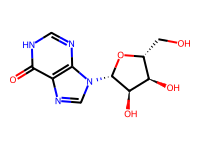
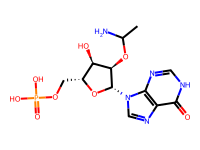
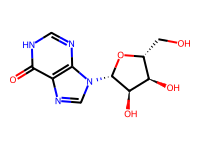
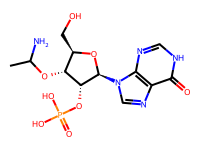
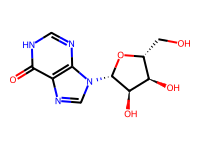
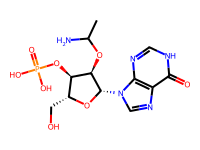
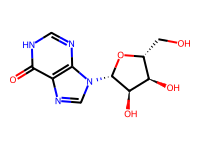
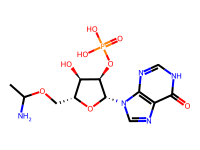
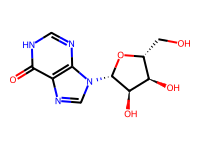
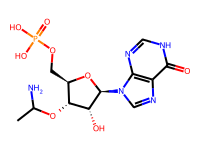
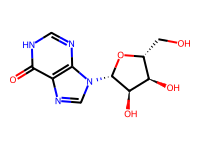
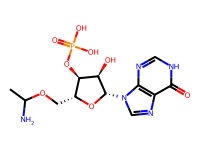
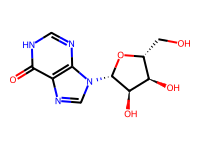
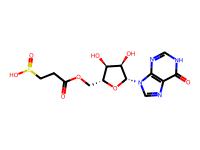
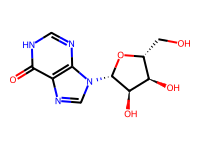
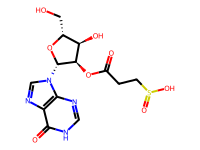
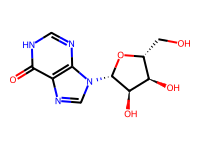
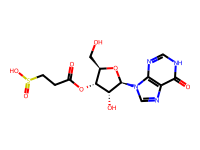
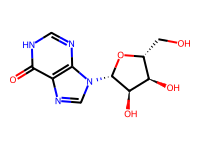
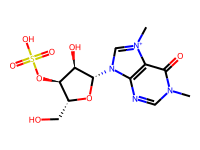

In [16]:
import base64
from io import BytesIO
from rdkit import DataStructs
from rdkit.Chem import rdMolDescriptors, Draw
from IPython.display import HTML, display

fpRadius, fpBits = 2, 2048

# Lipinski rule of five: 0 = compound must satisfy all four criteria;
# set to 1 for the classic "no more than one violation" form.
lipinskiMaxViolations = 0

def morganFp(mol):
    return rdMolDescriptors.GetMorganFingerprintAsBitVect(mol, fpRadius, nBits=fpBits) if mol is not None else None


physicochemicalCutoffs = {
    "mwMax"  : 700.0,
    "tpsaMax": 200.0,
    "hbdMax" : 7,
    "qedMin" : 0.10,
}


def buildCofactorExclusionSet(rawSmilesList):
    exclusionSet = set()
    for smi in rawSmilesList:
        mol = Chem.MolFromSmiles(smi)
        if mol is not None:
            exclusionSet.add(Chem.MolToSmiles(mol))
        else:
            print(f"  Warning: could not parse cofactor SMILES: {smi}")
    print(f"Cofactor exclusion set built: {len(exclusionSet)} entries resolved.")
    return exclusionSet


def isCofactorOrEndogenous(mol, canonSmi, cofactorExclusionSet, cutoffs):
    if mol is None:
        return True
    if canonSmi in cofactorExclusionSet:
        return True
    mw   = Descriptors.MolWt(mol)
    tpsa = rdMolDescriptors.CalcTPSA(mol)
    hbd  = rdMolDescriptors.CalcNumHBD(mol)
    if mw > cutoffs["mwMax"] or tpsa > cutoffs["tpsaMax"] or hbd > cutoffs["hbdMax"]:
        return True
    qed = QED.qed(mol)
    if qed < cutoffs["qedMin"]:
        return True
    return False


def lipinskiViolationCount(mol):
    if mol is None:
        return None
    violations = 0
    if Descriptors.MolWt(mol)           > 500:
        violations += 1
    if Descriptors.MolLogP(mol)         > 5:
        violations += 1
    if rdMolDescriptors.CalcNumHBD(mol) > 5:
        violations += 1
    if rdMolDescriptors.CalcNumHBA(mol) > 10:
        violations += 1
    return violations


def passesLipinski(canonSmi, maxViolations):
    violations = lipinskiViolationCount(Chem.MolFromSmiles(str(canonSmi)))
    return violations is not None and violations <= maxViolations


def preservesStarterScaffold(compoundMol, starterCanon, canonToStarterMol):
    starterMol = canonToStarterMol.get(starterCanon)
    if starterMol is None:
        starterMol = Chem.MolFromSmiles(str(starterCanon))
    if starterMol is None or compoundMol is None:
        return False
    return compoundMol.HasSubstructMatch(starterMol)


def starterSimilarityRange(mol, starterFpByCanon):
    productFp = morganFp(mol)
    if productFp is None or not starterFpByCanon:
        return None, None
    sims = [DataStructs.TanimotoSimilarity(productFp, starterFp) for starterFp in starterFpByCanon.values()]
    return max(sims), min(sims)


def nearestStarterBySimilarity(mol, starterFpByCanon):
    productFp = morganFp(mol)
    if productFp is None or not starterFpByCanon:
        return None, -1.0
    bestStarter    = None
    bestSimilarity = -1.0
    for starterCanon, starterFp in starterFpByCanon.items():
        similarity = DataStructs.TanimotoSimilarity(productFp, starterFp)
        if similarity > bestSimilarity:
            bestSimilarity = similarity
            bestStarter    = starterCanon
    return bestStarter, bestSimilarity


def molToImgTag(smi, size=(200, 150)):
    mol = Chem.MolFromSmiles(str(smi))
    if mol is None:
        return ""
    img = Draw.MolToImage(mol, size=size)
    buffer = BytesIO()
    img.save(buffer, format="PNG")
    encoded = base64.b64encode(buffer.getvalue()).decode("utf-8")
    return f'<img src="data:image/png;base64,{encoded}"/>'


def buildStarterDerivedSet(reactionDF, starterMols, canonStarterSet,
                           canonHelperSet, cofactorExclusionSet, cutoffs,
                           starterFpByCanon):
    molToReactionIdxs = defaultdict(list)
    for idx, row in reactionDF.iterrows():
        for smi in splitMoleculeString(row["reactants"]):
            molToReactionIdxs[canonSmiles(smi)].append(idx)

    # Value: (matchedStarter, generationDepth, keptSimilarity, runnerUpSimilarity)
    starterDerivedSet = {canonSmi: (canonSmi, 0, 1.0, None) for canonSmi, _ in starterMols}
    queue   = deque((canonSmi, 0) for canonSmi in canonStarterSet)
    visited = set(canonStarterSet)

    while queue:
        currentCanon, currentDepth = queue.popleft()

        if currentCanon in canonHelperSet:
            continue

        for rxnIdx in molToReactionIdxs.get(currentCanon, []):
            row = reactionDF.loc[rxnIdx]

            # Score every eligible product of this reaction against its nearest starter
            productScores = []
            for productSmi in splitMoleculeString(row["products"]):
                productCanon = canonSmiles(productSmi)

                if productCanon in canonHelperSet:
                    continue
                if productCanon in starterDerivedSet:
                    continue

                productMol = Chem.MolFromSmiles(str(productSmi))

                if isCofactorOrEndogenous(productMol, productCanon,
                                          cofactorExclusionSet, cutoffs):
                    continue

                matchedStarter, similarity = nearestStarterBySimilarity(productMol, starterFpByCanon)
                if matchedStarter is None:
                    continue

                productScores.append((similarity, productCanon, matchedStarter))

            if not productScores:
                continue

            # Highest-similarity product is kept; the next one is the runner-up
            productScores.sort(key=lambda t: t[0], reverse=True)
            keptSimilarity, bestProductCanon, bestMatchedStarter = productScores[0]
            runnerUpSimilarity = productScores[1][0] if len(productScores) > 1 else None

            if bestProductCanon not in visited:
                visited.add(bestProductCanon)
                starterDerivedSet[bestProductCanon] = (
                    bestMatchedStarter, currentDepth + 1, keptSimilarity, runnerUpSimilarity
                )
                queue.append((bestProductCanon, currentDepth + 1))

    return starterDerivedSet


cofactorExclusionSet = buildCofactorExclusionSet(COFACTOR_SMILES)

starterMols = [
    (canonSmiles(smi), Chem.MolFromSmiles(str(smi)))
    for smi in user_starters
    if Chem.MolFromSmiles(str(smi)) is not None
]
canonStarterSet   = {s for s, _ in starterMols}
canonHelperSet    = {canonSmiles(s) for s in helpersToExclude}
canonToStarterMol = {canonStarter: starterMol for canonStarter, starterMol in starterMols}
starterFpByCanon  = {
    canonStarter: morganFp(starterMol)
    for canonStarter, starterMol in starterMols
    if morganFp(starterMol) is not None
}

print("Running forward BFS tracing through reaction network...")
starterDerivedSet = buildStarterDerivedSet(
    reactionDF,
    starterMols,
    canonStarterSet,
    canonHelperSet,
    cofactorExclusionSet = cofactorExclusionSet,
    cutoffs              = physicochemicalCutoffs,
    starterFpByCanon     = starterFpByCanon,
)
print(f"Starter-derived molecules found (including starters): {len(starterDerivedSet):,}")

uniqueProductMolsList = allProductMols.dropna().unique().tolist()

productRecords         = []
excludedCofactorSmiles = []
excludedHelper         = 0
excludedStarter        = 0
excludedCofactor       = 0
excludedNonDerived     = 0

for smi in uniqueProductMolsList:
    mol      = Chem.MolFromSmiles(str(smi))
    canonSmi = Chem.MolToSmiles(mol) if mol else None

    if canonSmi is None:
        continue
    if canonSmi in canonHelperSet:
        excludedHelper += 1
        continue
    if canonSmi in canonStarterSet:
        excludedStarter += 1
        continue
    if isCofactorOrEndogenous(mol, canonSmi, cofactorExclusionSet, physicochemicalCutoffs):
        excludedCofactor += 1
        excludedCofactorSmiles.append(canonSmi)
        continue
    if canonSmi not in starterDerivedSet:
        excludedNonDerived += 1
        continue

    matchedRaw, generationDepth, keptSimilarity, runnerUpSimilarity = starterDerivedSet.get(
        canonSmi, (None, None, None, None)
    )
    starterCanonicalSmiles = canonSmiles(matchedRaw) if matchedRaw else None

    productRecords.append({
        "starter_Canonical_SMILES" : starterCanonicalSmiles,
        "Canonical_SMILES"         : canonSmi,
        "generationSteps"          : generationDepth,
        "DerivativeSimScore"       : round(keptSimilarity, 4) if keptSimilarity is not None else None,
        "NonDerivativeSimScore"    : round(runnerUpSimilarity, 4) if runnerUpSimilarity is not None else None,
        "_molecularWeight"         : round(Descriptors.MolWt(mol), 4),
    })

generatedCompoundsDfRaw = pd.DataFrame(productRecords)

nBeforeDedup = len(generatedCompoundsDfRaw)

generatedCompoundsDfDedup = (
    generatedCompoundsDfRaw
    .drop_duplicates(subset="Canonical_SMILES", keep="first")
    .reset_index(drop=True)
)
nAfterDedup = len(generatedCompoundsDfDedup)

# Keep only compounds that satisfy Lipinski's rule of five
lipinskiMask = generatedCompoundsDfDedup["Canonical_SMILES"].apply(
    lambda s: passesLipinski(s, lipinskiMaxViolations)
)
generatedCompoundsDfLipinski = generatedCompoundsDfDedup[lipinskiMask].reset_index(drop=True)
nAfterLipinski = len(generatedCompoundsDfLipinski)

# Sort by descending molecular weight, then drop the helper weight column
generatedCompoundsDF = (
    generatedCompoundsDfLipinski
    .sort_values("_molecularWeight", ascending=False)
    .drop(columns="_molecularWeight")
    .reset_index(drop=True)
)

# Candidate list ordered by descending molecular weight
generatedCompoundsList = generatedCompoundsDF["Canonical_SMILES"].tolist()

# Scaffold preservation computed only for reporting (not stored in the frame or CSV)
scaffoldFlags = generatedCompoundsDF.apply(
    lambda r: preservesStarterScaffold(
        Chem.MolFromSmiles(str(r["Canonical_SMILES"])),
        r["starter_Canonical_SMILES"],
        canonToStarterMol,
    ),
    axis=1,
)
nDerivative    = int(scaffoldFlags.sum())
nNonDerivative = int((~scaffoldFlags).sum())

# Save the clean SMILES/score table before adding structure images
generatedCompoundsCsvPath = f"{fileNamePrefix}_generated_compounds.csv"
generatedCompoundsDF.to_csv(generatedCompoundsCsvPath, index=False)

print(f"Unique product molecules total        : {len(uniqueProductMolsList):,}")
print(f"Excluded as helpers                   : {excludedHelper:,}")
print(f"Excluded as starters                  : {excludedStarter:,}")
print(f"Excluded as cofactors / endogenous    : {excludedCofactor:,}")
print(f"Excluded as non-derived               : {excludedNonDerived:,}")
print(f"Compounds before deduplication        : {nBeforeDedup:,}")
print(f"Compounds after deduplication         : {nAfterDedup:,}")
print(f"Compounds after Lipinski rule of 5    : {nAfterLipinski:,}")
print(f"Removed by Lipinski filter            : {nAfterDedup - nAfterLipinski:,}")
print(f"Scaffold-preserving (Derivative)      : {nDerivative:,}")
print(f"Scaffold-modified (Non-derivative)    : {nNonDerivative:,}")
print(f"\nGeneration-step distribution:")
print(generatedCompoundsDF["generationSteps"].value_counts(dropna=False).sort_index().to_string())
print(f"\nCandidates in list (descending MW)    : {len(generatedCompoundsList):,}")
print(f"\nSaved to: {generatedCompoundsCsvPath}")

# Add rendered structures for inline display (not written to the CSV)
generatedCompoundsDF["starterStructure"] = generatedCompoundsDF["starter_Canonical_SMILES"].apply(molToImgTag)
generatedCompoundsDF["productStructure"] = generatedCompoundsDF["Canonical_SMILES"].apply(molToImgTag)

displayColumns = [
    "starter_Canonical_SMILES", "starterStructure",
    "Canonical_SMILES", "productStructure",
    "generationSteps", "DerivativeSimScore", "NonDerivativeSimScore",
]
generatedCompoundsDF = generatedCompoundsDF[displayColumns]

display(HTML(generatedCompoundsDF.head(10).to_html(escape=False)))

In [17]:
multiProductRows = generatedCompoundsDF[generatedCompoundsDF["NonDerivativeSimScore"].notna()]

print(f"Rows with more than one eligible product: {len(multiProductRows):,} of {len(generatedCompoundsDF):,}")

cols = ["starter_Canonical_SMILES", "Canonical_SMILES",
        "generationSteps", "DerivativeSimScore", "NonDerivativeSimScore"]
multiProductRows[cols].head(5)

Rows with more than one eligible product: 44 of 4,122


,starter_Canonical_SMILES,Canonical_SMILES,generationSteps,DerivativeSimScore,NonDerivativeSimScore
658,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,O=c1[nH]cnc2c1[nH+]cn2[C@@H]1O[C@H](CO)[C@@H](...,3,0.4762,0.3380
659,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,O=c1[nH]cnc2c1[nH+]cn2[C@@H]1O[C@H](COS(=O)(=O...,3,0.4677,0.3286
660,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,O=c1[nH]cnc2c1[nH+]cn2[C@@H]1O[C@H](CO)[C@@H](...,3,0.4762,0.3380
661,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,O=c1[nH]cnc2c1[nH+]cn2[C@@H]1O[C@H](COP(=O)(O)...,3,0.4677,0.3286
662,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,O=c1[nH]cnc2c1[nH+]cn2[C@@H]1O[C@H](CO)[C@@H](...,3,0.4762,0.3380


### Select `structurally` diverse compounds from the generated compound list

### Visualize `product` compounds

Selecting structurally diverse compounds via MaxMinPicker...
Selected 18 compounds from 4,122 total.
Row 01 saved: InosineOnly_gen3_row01.png  |  InosineOnly_gen3_row01.pdf
Row 02 saved: InosineOnly_gen3_row02.png  |  InosineOnly_gen3_row02.pdf
Row 03 saved: InosineOnly_gen3_row03.png  |  InosineOnly_gen3_row03.pdf
Row 04 saved: InosineOnly_gen3_row04.png  |  InosineOnly_gen3_row04.pdf
Row 05 saved: InosineOnly_gen3_row05.png  |  InosineOnly_gen3_row05.pdf
Row 06 saved: InosineOnly_gen3_row06.png  |  InosineOnly_gen3_row06.pdf

6 row figures saved individually at 600 DPI.


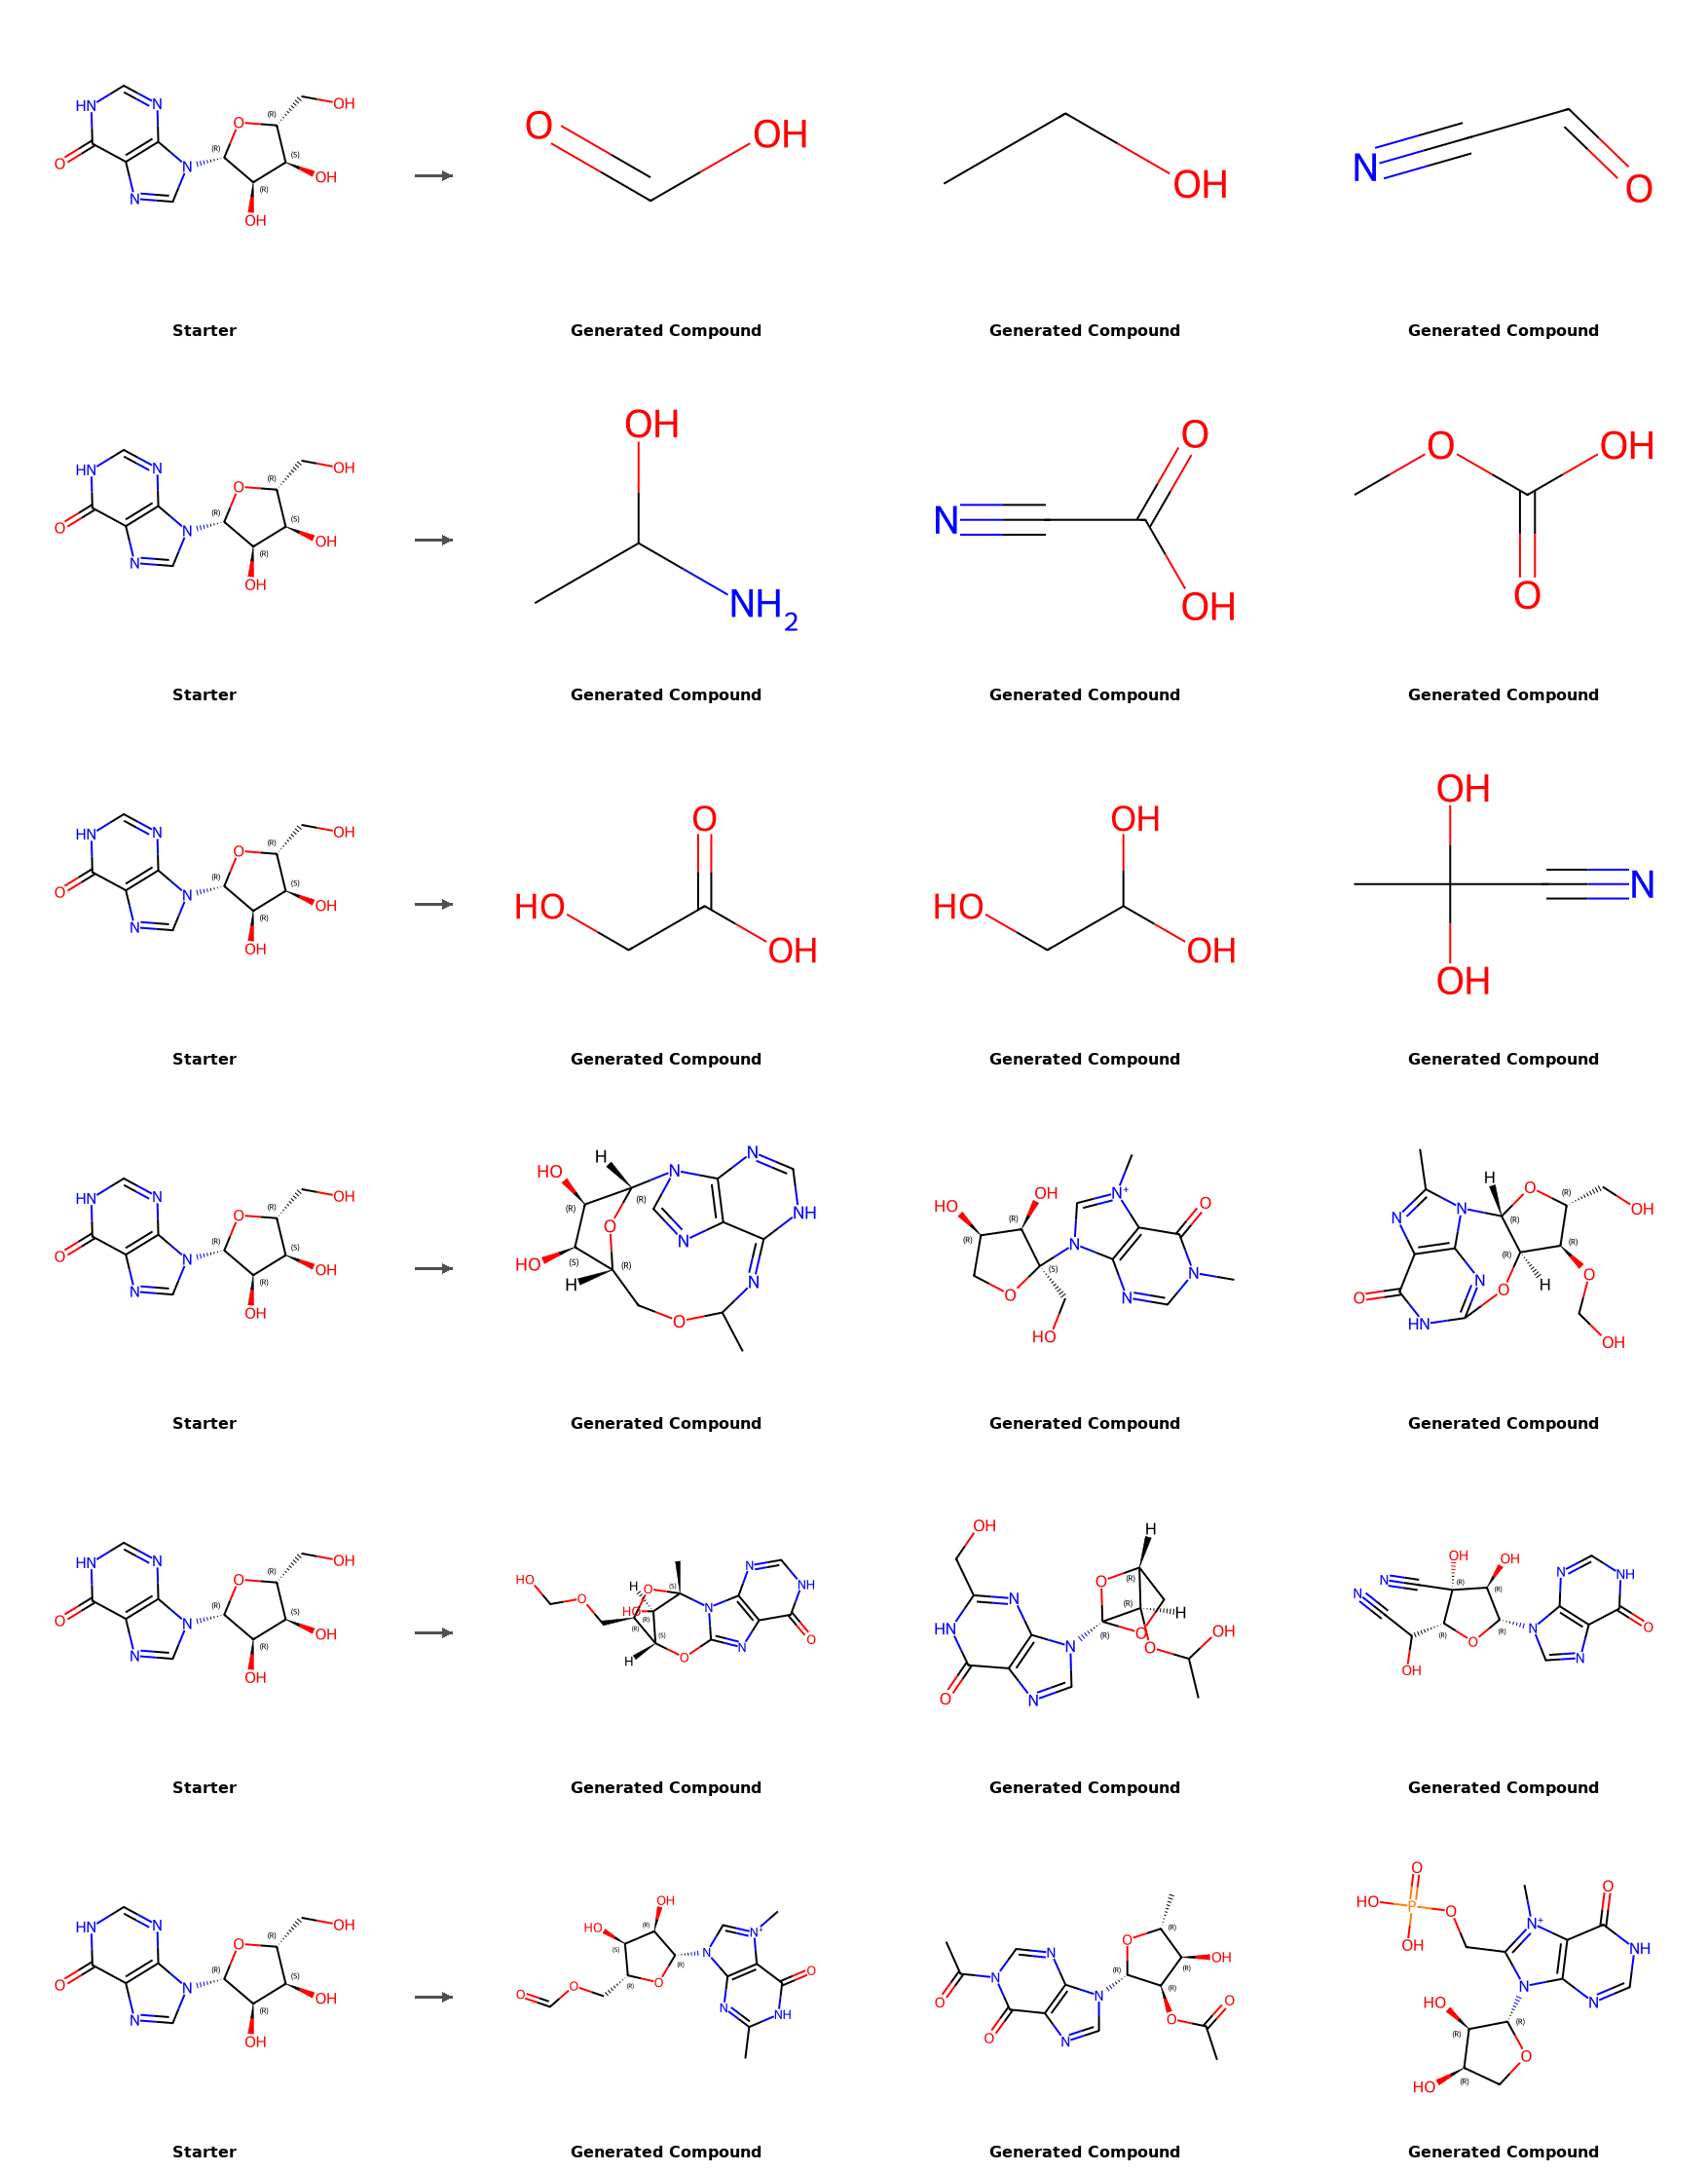

In [50]:
nTargetsTotal   = 18
nTargetsPerRow  = 3
molCellW        = 420
molCellH        = 320
labelH          = 40
arrowZoneW      = 54
targetGap       = 10
dpi             = 600

white           = (255, 255, 255)
black           = (0,   0,   0  )
arrowColor      = (80,  80,  80 )

fontBoldPath    = "/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf"


def loadFont(path, size):
    try:
        return ImageFont.truetype(path, size)
    except Exception:
        return ImageFont.load_default()


def renderMolToPil(mol, w, h):
    try:
        drawer = rdMolDraw2D.MolDraw2DCairo(w, h)
        drawer.drawOptions().addStereoAnnotation = True
        drawer.drawOptions().padding = 0.12
        rdMolDraw2D.PrepareMolForDrawing(mol)
        drawer.DrawMolecule(mol)
        drawer.FinishDrawing()
        return Image.open(io.BytesIO(drawer.GetDrawingText())).convert("RGB")
    except Exception:
        from rdkit.Chem import Draw
        return Draw.MolToImage(mol, size=(w, h))


def selectDiverseIdxs(smilesList, nSelect, seed=42):
    fps, validIdxs = [], []
    for i, smi in enumerate(smilesList):
        mol = Chem.MolFromSmiles(smi)
        if mol is not None:
            fps.append(AllChem.GetMorganFingerprintAsBitVect(mol, 2, 2048))
            validIdxs.append(i)

    nSelect = min(nSelect, len(fps))

    def distFunc(i, j, fps=fps):
        return 1.0 - DataStructs.TanimotoSimilarity(fps[i], fps[j])

    picker      = MaxMinPicker()
    pickedLocal = list(picker.LazyPick(distFunc, len(fps), nSelect, seed=seed))
    return sorted([validIdxs[k] for k in pickedLocal])


def drawMolCell(mol, cellW, cellH, molH, label, fontBold):
    cell = Image.new("RGB", (cellW, cellH), white)
    ctx  = ImageDraw.Draw(cell)

    if mol is not None:
        molImg = renderMolToPil(mol, cellW - 16, molH - 8)
        cell.paste(molImg, (8, 4))

    bb  = ctx.textbbox((0, 0), label, font=fontBold)
    lW  = bb[2] - bb[0]
    ctx.text(((cellW - lW) // 2, molH + 10), label, fill=black, font=fontBold)
    return cell


def pasteArrow(canvas, x, y, length=34, color=arrowColor):
    d = ImageDraw.Draw(canvas)
    d.line([(x, y), (x + length, y)], fill=color, width=3)
    headL, headW = 10, 5
    d.polygon([
        (x + length,          y),
        (x + length - headL,  y - headW),
        (x + length - headL,  y + headW),
    ], fill=color)


def buildRowCanvas(starterMol, targetMols, fontBold):
    cellH = molCellH + labelH
    rowW  = (molCellW + arrowZoneW +
             nTargetsPerRow * molCellW +
             (nTargetsPerRow - 1) * targetGap)

    canvas      = Image.new("RGB", (rowW, cellH), white)
    starterCell = drawMolCell(starterMol, molCellW, cellH, molCellH, "Starter", fontBold)
    canvas.paste(starterCell, (0, 0))

    pasteArrow(canvas, x=molCellW + 6, y=cellH // 2, length=arrowZoneW - 16)

    for tIdx, targetMol in enumerate(targetMols):
        cellX      = molCellW + arrowZoneW + tIdx * (molCellW + targetGap)
        targetCell = drawMolCell(targetMol, molCellW, cellH, molCellH,
                                 "Generated Compound", fontBold)
        canvas.paste(targetCell, (cellX, 0))

    return canvas


print("Selecting structurally diverse compounds via MaxMinPicker...")
diverseIdxs = selectDiverseIdxs(
    generatedCompoundsDF["Canonical_SMILES"].tolist(),
    nTargetsTotal,
)
selectedDF = (
    generatedCompoundsDF
    .iloc[diverseIdxs]
    .copy()
    .reset_index(drop=True)
)
print(f"Selected {len(selectedDF)} compounds from {len(generatedCompoundsDF):,} total.")

rows = []
for starterSmi, grp in selectedDF.groupby("starter_Canonical_SMILES", sort=False):
    targets = grp["Canonical_SMILES"].tolist()
    for i in range(0, len(targets), nTargetsPerRow):
        batch = targets[i : i + nTargetsPerRow]
        while len(batch) < nTargetsPerRow:
            batch.append(None)
        rows.append({"starterSmi": starterSmi, "targets": batch})

fontBold    = loadFont(fontBoldPath, 16)
rowCanvases = []

for rowIdx, rowData in enumerate(rows):
    starterMol = Chem.MolFromSmiles(rowData["starterSmi"])
    targetMols = [
        Chem.MolFromSmiles(smi) if smi else None
        for smi in rowData["targets"]
    ]

    rowCanvas = buildRowCanvas(starterMol, targetMols, fontBold)
    rowCanvases.append(rowCanvas)

    pngPath = f"{fileNamePrefix}_row{rowIdx + 1:02d}.png"
    pdfPath = f"{fileNamePrefix}_row{rowIdx + 1:02d}.pdf"
    rowCanvas.save(pngPath, format="PNG", dpi=(dpi, dpi))
    rowCanvas.save(pdfPath, format="PDF", resolution=dpi)
    print(f"Row {rowIdx + 1:02d} saved: {pngPath}  |  {pdfPath}")

rowGap     = 14
rowCellH   = molCellH + labelH
fullW      = rowCanvases[0].width
fullH      = len(rowCanvases) * rowCellH + (len(rowCanvases) - 1) * rowGap
fullCanvas = Image.new("RGB", (fullW, fullH), white)

for i, rc in enumerate(rowCanvases):
    fullCanvas.paste(rc, (0, i * (rowCellH + rowGap)))

print(f"\n{len(rows)} row figures saved individually at {dpi} DPI.")
fullCanvas

### Print `pathway` level details

In [18]:
def buildReactionIndex(reactionDF, canonHelperSet):
    molToRxnIdxs = defaultdict(list)
    rxnProducts  = {}

    for idx, row in reactionDF.iterrows():
        for smi in splitMoleculeString(row["reactants"]):
            c = canonSmiles(smi)
            if c not in canonHelperSet:
                molToRxnIdxs[c].append(idx)

        rxnProducts[idx] = frozenset(
            canonSmiles(s) for s in splitMoleculeString(row["products"])
            if canonSmiles(s) not in canonHelperSet
        )

    return molToRxnIdxs, rxnProducts


def countChainsToTargets(starterCanon, targetCanonSet, molToRxnIdxs,
                         rxnProducts, starterMols, maxDepth=3):
    scaffoldCache = {}

    def isScaffoldBearing(canonSmi):
        if canonSmi not in scaffoldCache:
            mol = Chem.MolFromSmiles(canonSmi)
            scaffoldCache[canonSmi] = (
                mol is not None and
                any(mol.HasSubstructMatch(starterMol) for _, starterMol in starterMols)
            )
        return scaffoldCache[canonSmi]

    def productsHaveScaffold(products):
        return any(isScaffoldBearing(m) for m in products)

    counts        = defaultdict(lambda: defaultdict(int))
    queue         = deque()
    statesVisited = 0

    for rxnIdx in molToRxnIdxs.get(starterCanon, []):
        products = rxnProducts[rxnIdx]
        chain    = (rxnIdx,)

        for target in products & targetCanonSet:
            counts[target][1] += 1

        if maxDepth > 1:
            queue.append((chain, products, frozenset({rxnIdx})))

    while queue:
        chain, availMols, visitedRxns = queue.popleft()
        statesVisited += 1
        depth = len(chain)

        if depth >= maxDepth:
            continue

        for mol in availMols:
            for rxnIdx in molToRxnIdxs.get(mol, []):
                if rxnIdx in visitedRxns:
                    continue

                products  = rxnProducts[rxnIdx]
                newChain  = chain + (rxnIdx,)
                newDepth  = len(newChain)

                for target in products & targetCanonSet:
                    counts[target][newDepth] += 1

                if newDepth < maxDepth:
                    newState = (newChain, products, visitedRxns | {rxnIdx})
                    if productsHaveScaffold(products):
                        queue.appendleft(newState)
                    else:
                        queue.append(newState)

    return counts, statesVisited


print("Building reaction index...")
molToRxnIdxs, rxnProducts = buildReactionIndex(reactionDF, canonHelperSet)
print(f"Indexed {len(molToRxnIdxs):,} unique non-helper reactant molecules.")
print(f"Indexed {len(rxnProducts):,} reactions.\n")

totalCompounds = len(generatedCompoundsDF)
print(f"Total compounds after deduplication (generatedCompoundsDF): {totalCompounds:,}\n")

summaryRecords     = []
perStarterSummary  = []

for starterSmi, group in generatedCompoundsDF.groupby("starter_Canonical_SMILES"):
    targetCanonSet  = set(group["Canonical_SMILES"].tolist())
    nTargets        = len(targetCanonSet)

    print(f"Starter : {starterSmi[:70]}")
    print(f"  Compounds from this starter  : {nTargets:,}")

    counts, statesVisited = countChainsToTargets(
        starterSmi,
        targetCanonSet,
        molToRxnIdxs,
        rxnProducts,
        starterMols = starterMols,
        maxDepth    = doranet_generations,
    )

    nWithPath    = sum(1 for t in targetCanonSet if counts.get(t))
    nWithoutPath = nTargets - nWithPath
    coverage     = nWithPath / nTargets * 100 if nTargets > 0 else 0.0

    print(f"  BFS states explored          : {statesVisited:,}")
    print(f"  With atlest one pathway              : {nWithPath:,}  ({coverage:.1f}%)")
    print(f"  With zero pathways           : {nWithoutPath:,}")
    print()

    perStarterSummary.append({
        "starter_Canonical_SMILES" : starterSmi,
        "total_compounds"          : nTargets,
        "compounds_with_pathway"   : nWithPath,
        "compounds_without_pathway": nWithoutPath,
        "pathway_coverage_pct"     : round(coverage, 2),
    })

    for _, row in group.iterrows():
        targetSmi    = row["Canonical_SMILES"]
        targetCounts = counts.get(targetSmi, {})
        n1 = targetCounts.get(1, 0)
        n2 = targetCounts.get(2, 0)
        n3 = targetCounts.get(3, 0)

        summaryRecords.append({
            "starter_Canonical_SMILES" : starterSmi,
            "Canonical_SMILES"         : targetSmi,
            "1step_pathways"           : n1,
            "2step_pathways"           : n2,
            "3step_pathways"           : n3,
            "total_pathways"           : n1 + n2 + n3,
        })

pathSummaryDF = (
    pd.DataFrame(summaryRecords)
    .sort_values(
        ["starter_Canonical_SMILES", "total_pathways"],
        ascending=[True, False],
    )
    .reset_index(drop=True)
)

perStarterSummaryDF = pd.DataFrame(perStarterSummary)

nZero    = (pathSummaryDF["total_pathways"] == 0).sum()
nNonZero = (pathSummaryDF["total_pathways"] >  0).sum()


if nZero > 0:
    print(f"\n  Note: {nZero} zero-pathway compounds persist after exhaustive BFS.")
    print(f"  This indicates a canonicalization mismatch between")
    print(f"  buildStarterDerivedSet and countChainsToTargets.")

pathSummaryDF

Building reaction index...
Indexed 270 unique non-helper reactant molecules.
Indexed 8,820 reactions.

Total compounds after deduplication (generatedCompoundsDF): 4,122

Starter : O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O
  Compounds from this starter  : 4,122
  BFS states explored          : 4,540
  With atlest one pathway              : 4,122  (100.0%)
  With zero pathways           : 0



,starter_Canonical_SMILES,Canonical_SMILES,1step_pathways,2step_pathways,3step_pathways,total_pathways
0,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,CC(=O)O[C@H]1[C@@H](O)[C@H](n2cnc3c(=O)[nH]cnc...,1,38,22265,22304
1,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,CC(=O)O[C@@H]1[C@H](O)[C@@H](CO)O[C@H]1n1cnc2c...,1,38,22265,22304
2,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,O=C[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@H](O)...,2,81,18877,18960
3,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,CC(=O)OC[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@...,1,38,18704,18743
4,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,O=CO,0,26,12493,12519
...,...,...,...,...,...,...
4117,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@@H]2CO[C@@]1(O)[C...,0,0,1,1
4118,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,O=CO[C@@H]1CO[C@@H](n2cnc3c(=O)[nH]cnc32)[C@@H]1O,0,0,1,1
4119,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,O=CO[C@@H]1[C@H](O)CO[C@H]1n1cnc2c(=O)[nH]cnc21,0,0,1,1
4120,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@@H]2CO[C@]2(O)[C@...,0,0,1,1


### Visualize `starter → product` reaction pathways from the network

Searching for 1-step, 2-step, and 3-step pathway chains...
  1-step pathways found: 3
  2-step pathways found: 3
  3-step pathways found: 3
Saved: InosineOnly_gen3_step1_pathway1.png  |  InosineOnly_gen3_step1_pathway1.pdf


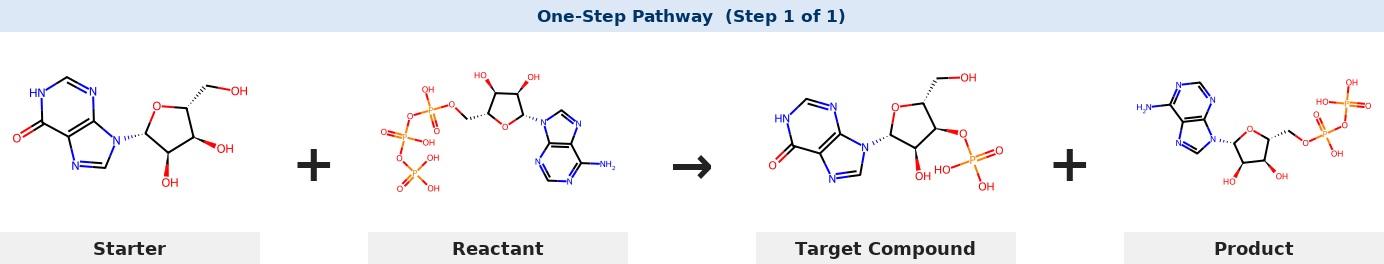

Saved: InosineOnly_gen3_step1_pathway2.png  |  InosineOnly_gen3_step1_pathway2.pdf


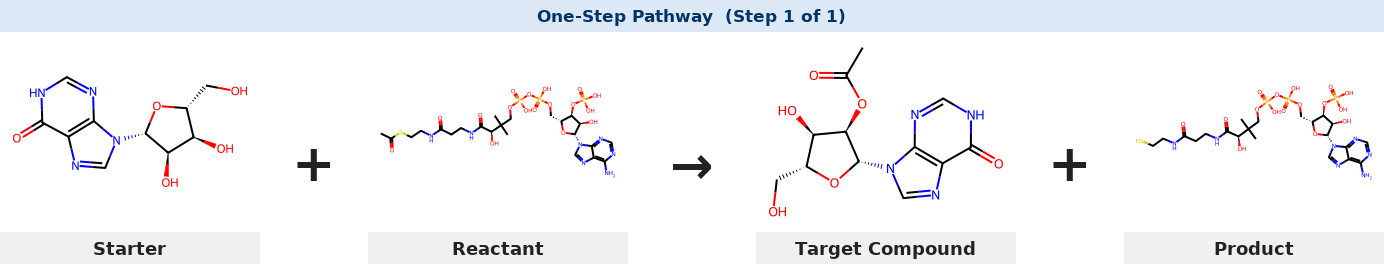

Saved: InosineOnly_gen3_step1_pathway3.png  |  InosineOnly_gen3_step1_pathway3.pdf


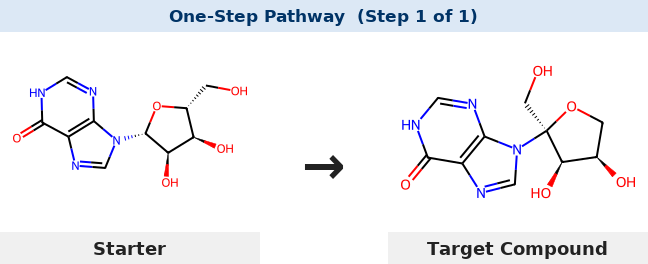

Saved: InosineOnly_gen3_step2_pathway1.png  |  InosineOnly_gen3_step2_pathway1.pdf


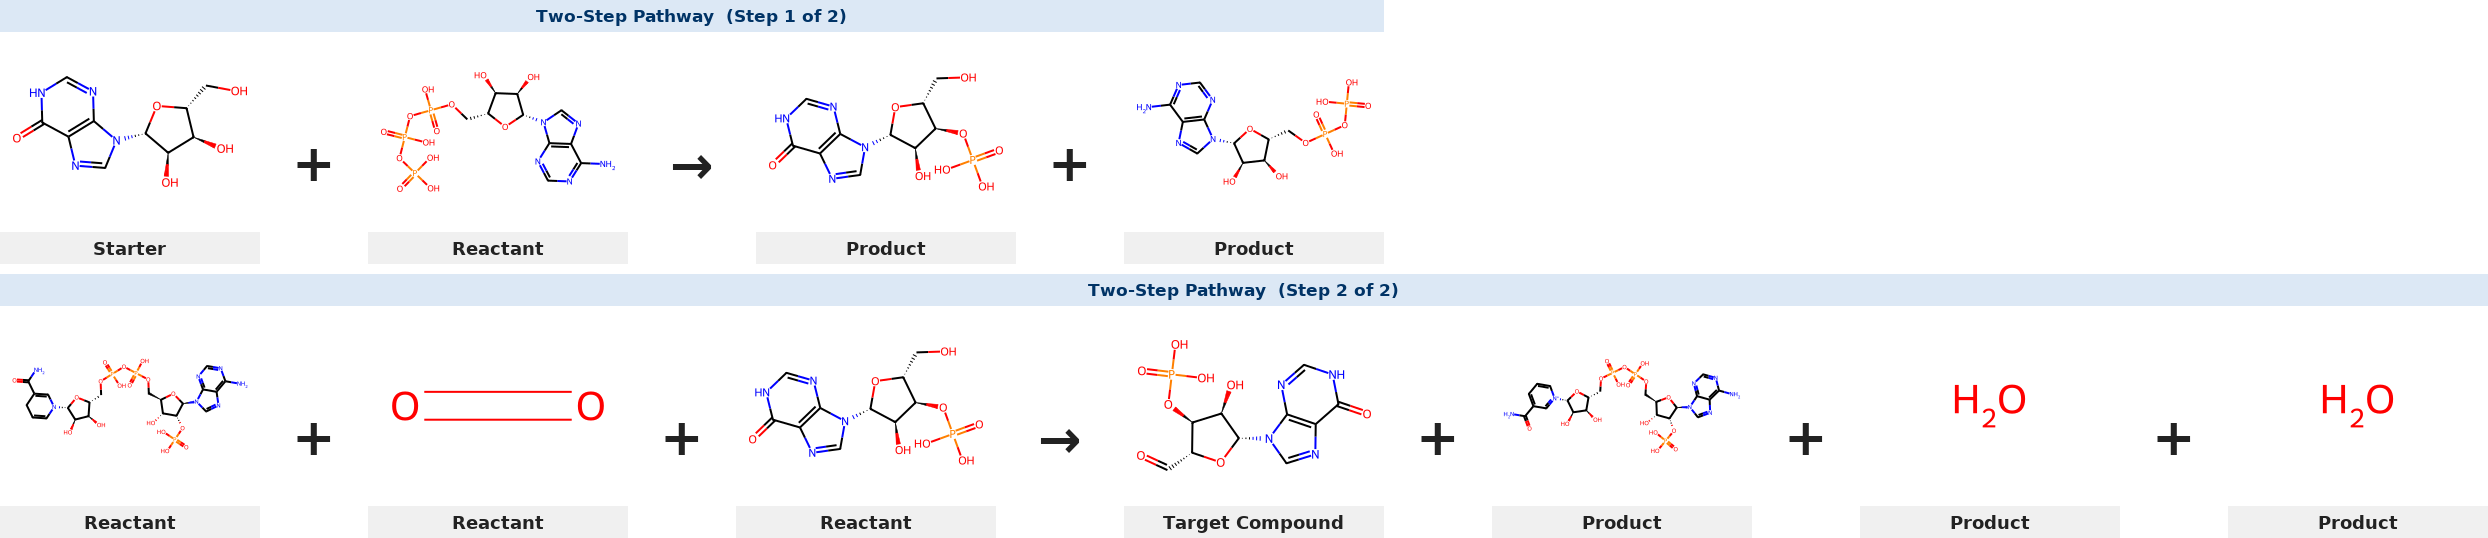

Saved: InosineOnly_gen3_step2_pathway2.png  |  InosineOnly_gen3_step2_pathway2.pdf


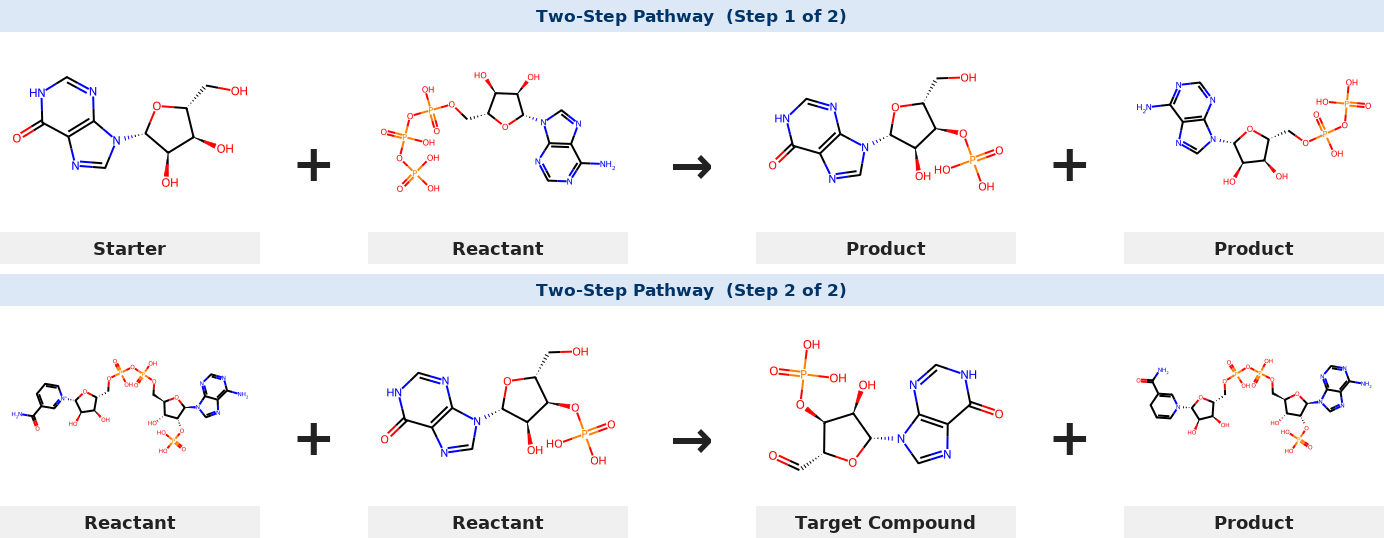

Saved: InosineOnly_gen3_step2_pathway3.png  |  InosineOnly_gen3_step2_pathway3.pdf


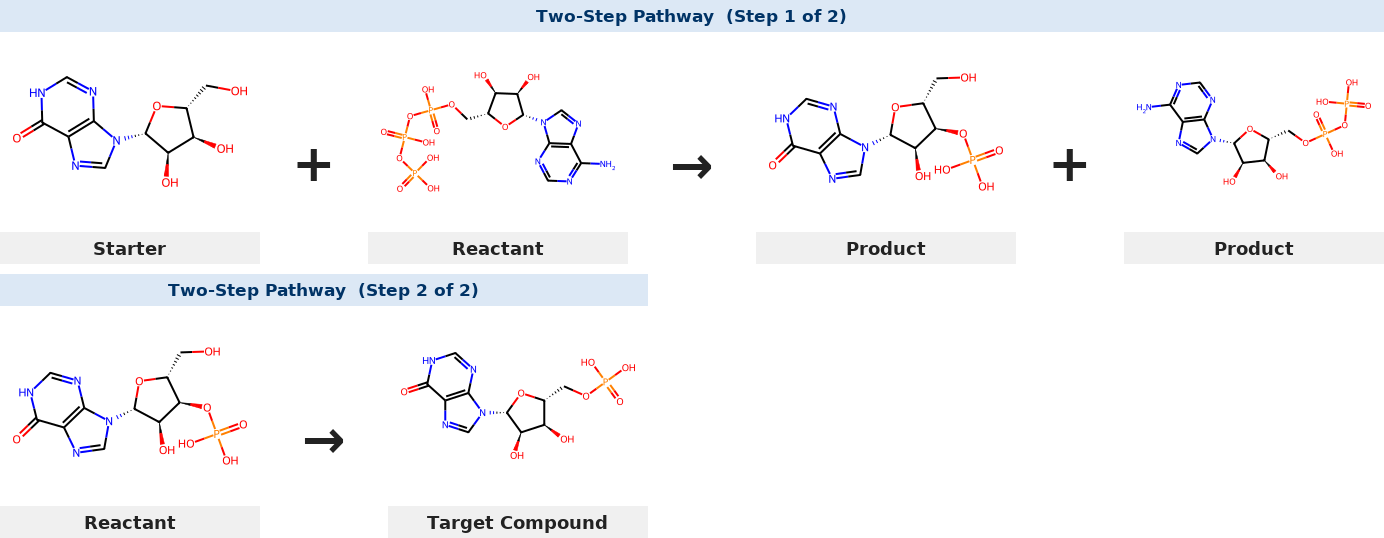

Saved: InosineOnly_gen3_step3_pathway1.png  |  InosineOnly_gen3_step3_pathway1.pdf


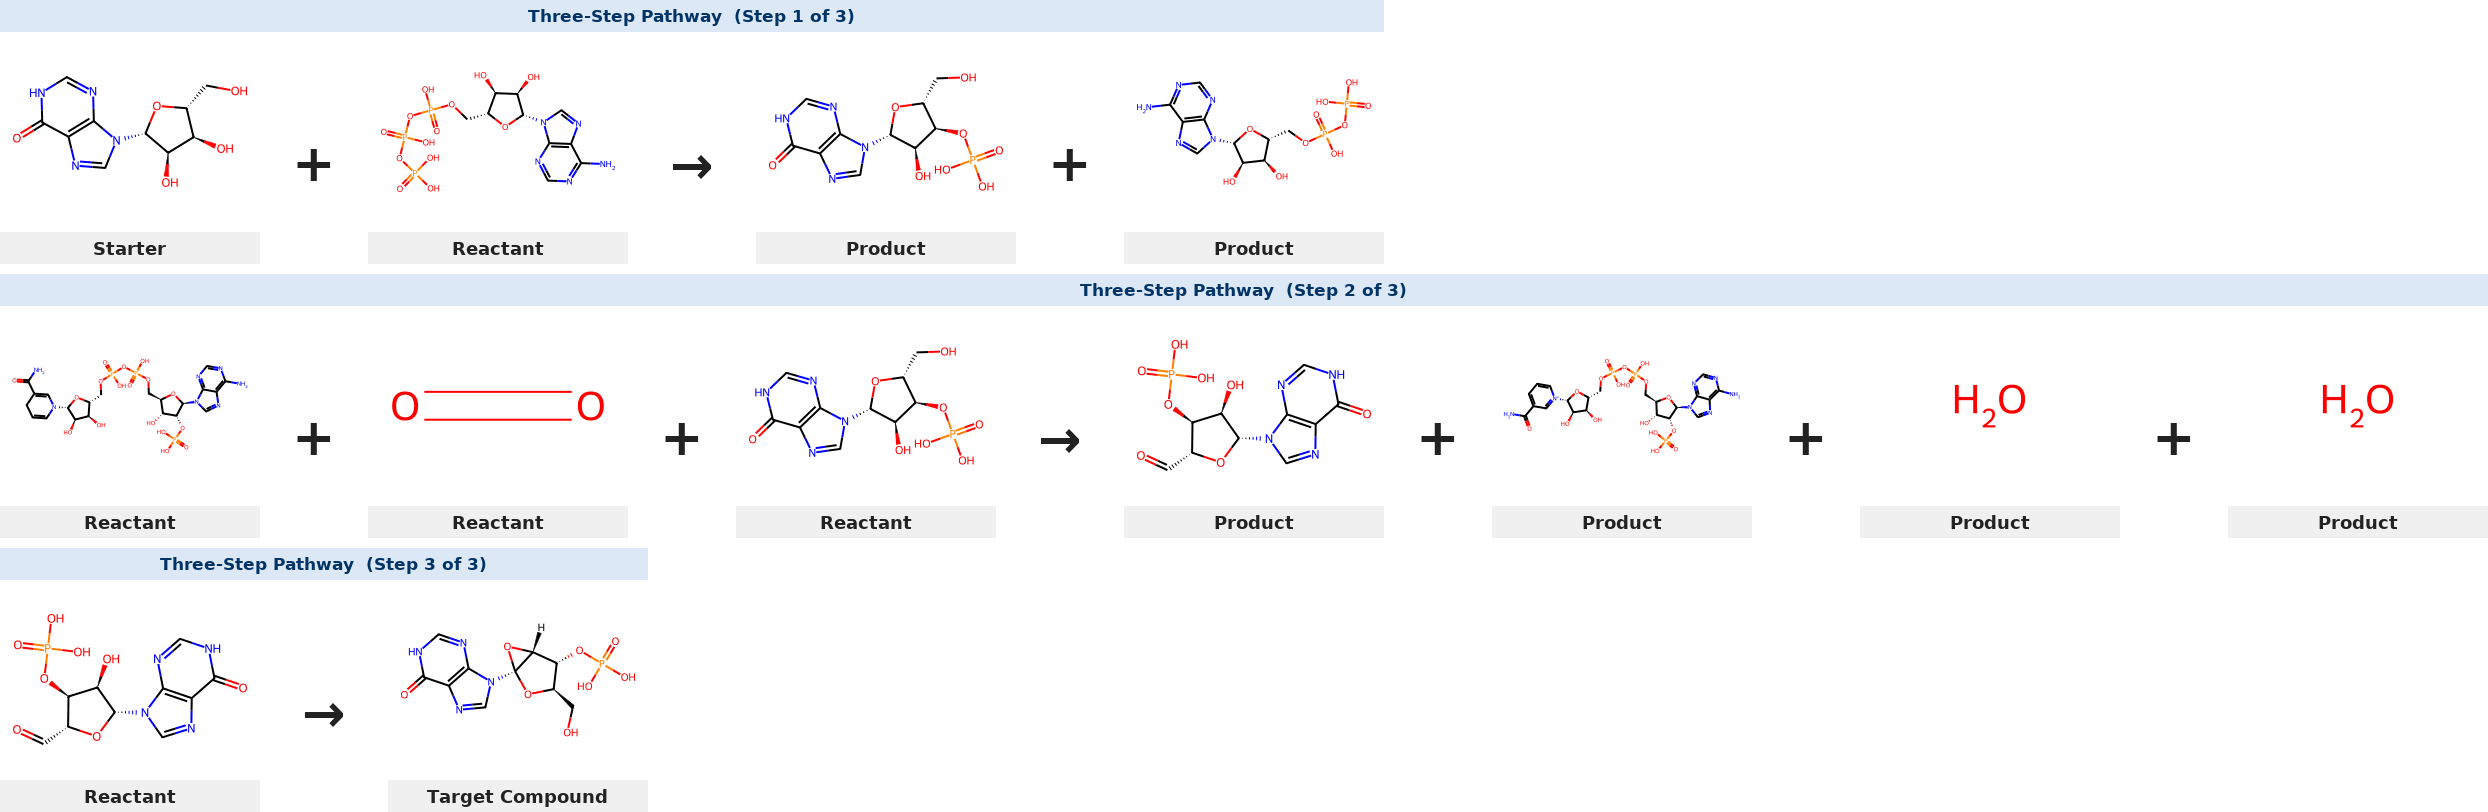

Saved: InosineOnly_gen3_step3_pathway2.png  |  InosineOnly_gen3_step3_pathway2.pdf


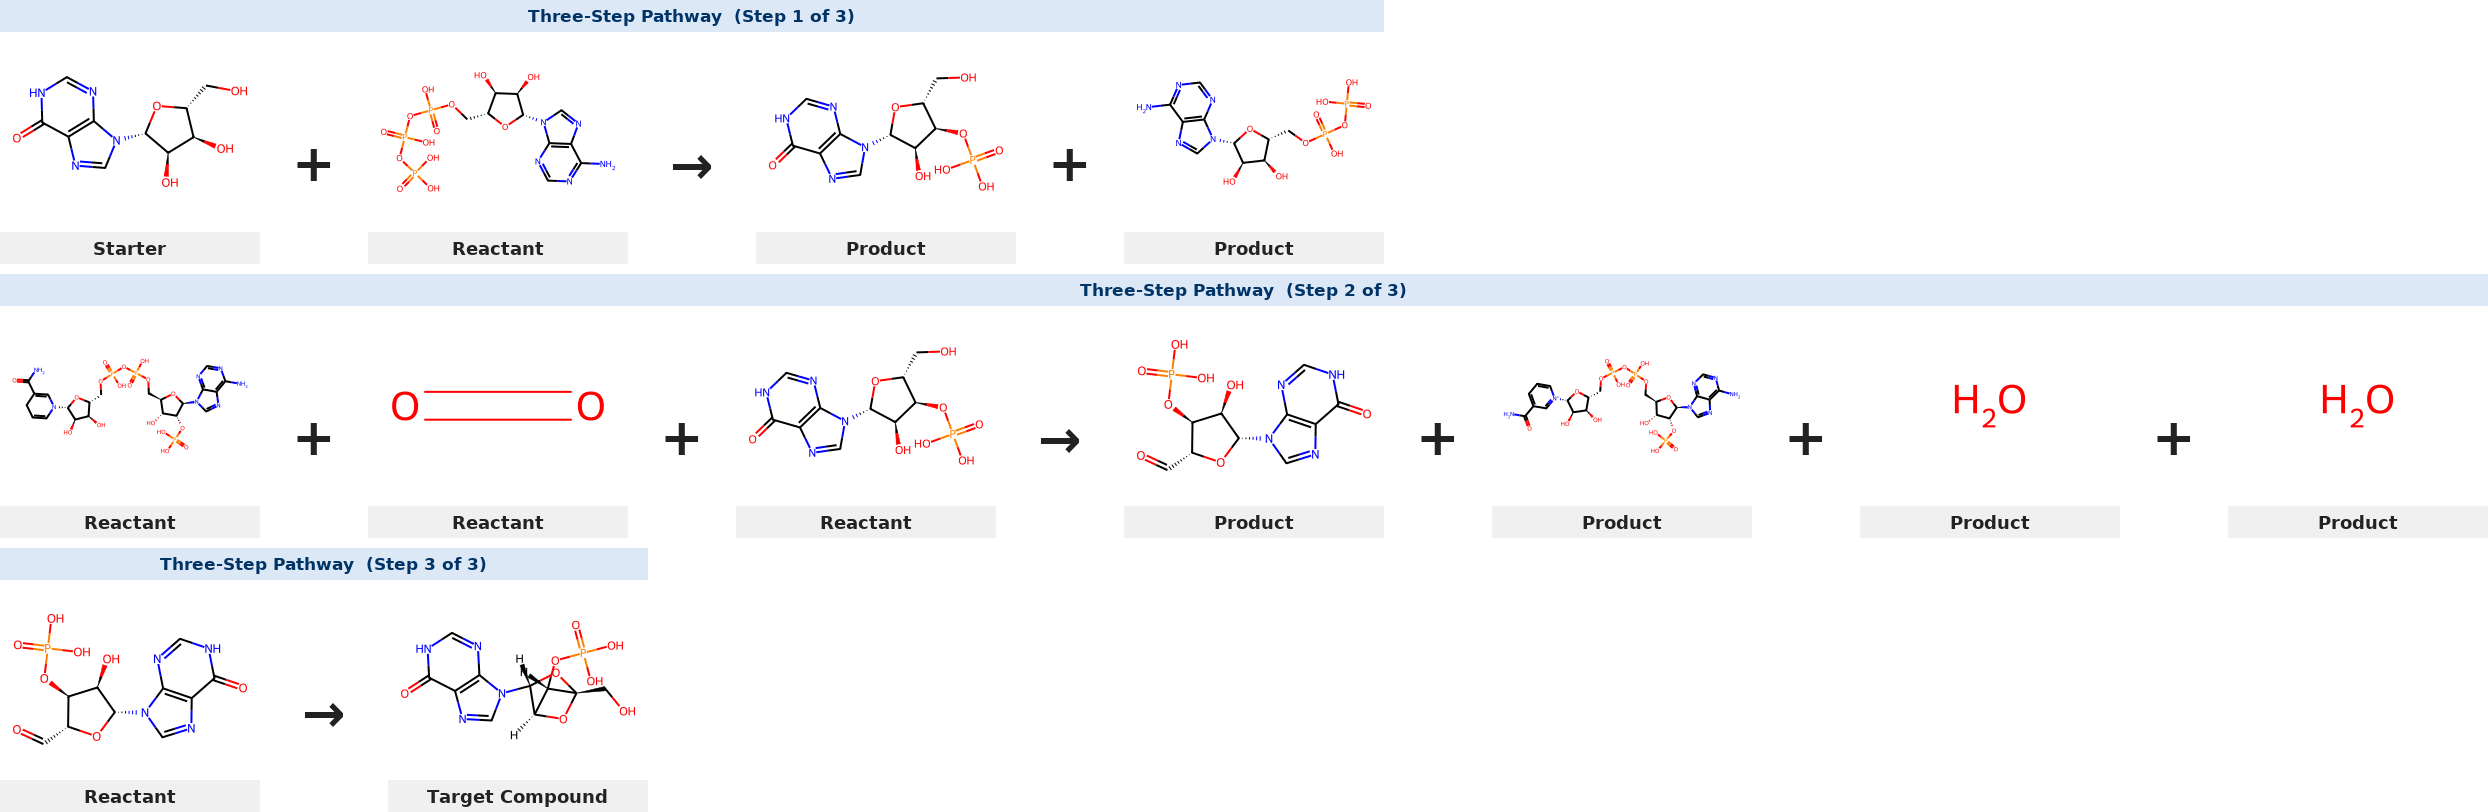

Saved: InosineOnly_gen3_step3_pathway3.png  |  InosineOnly_gen3_step3_pathway3.pdf


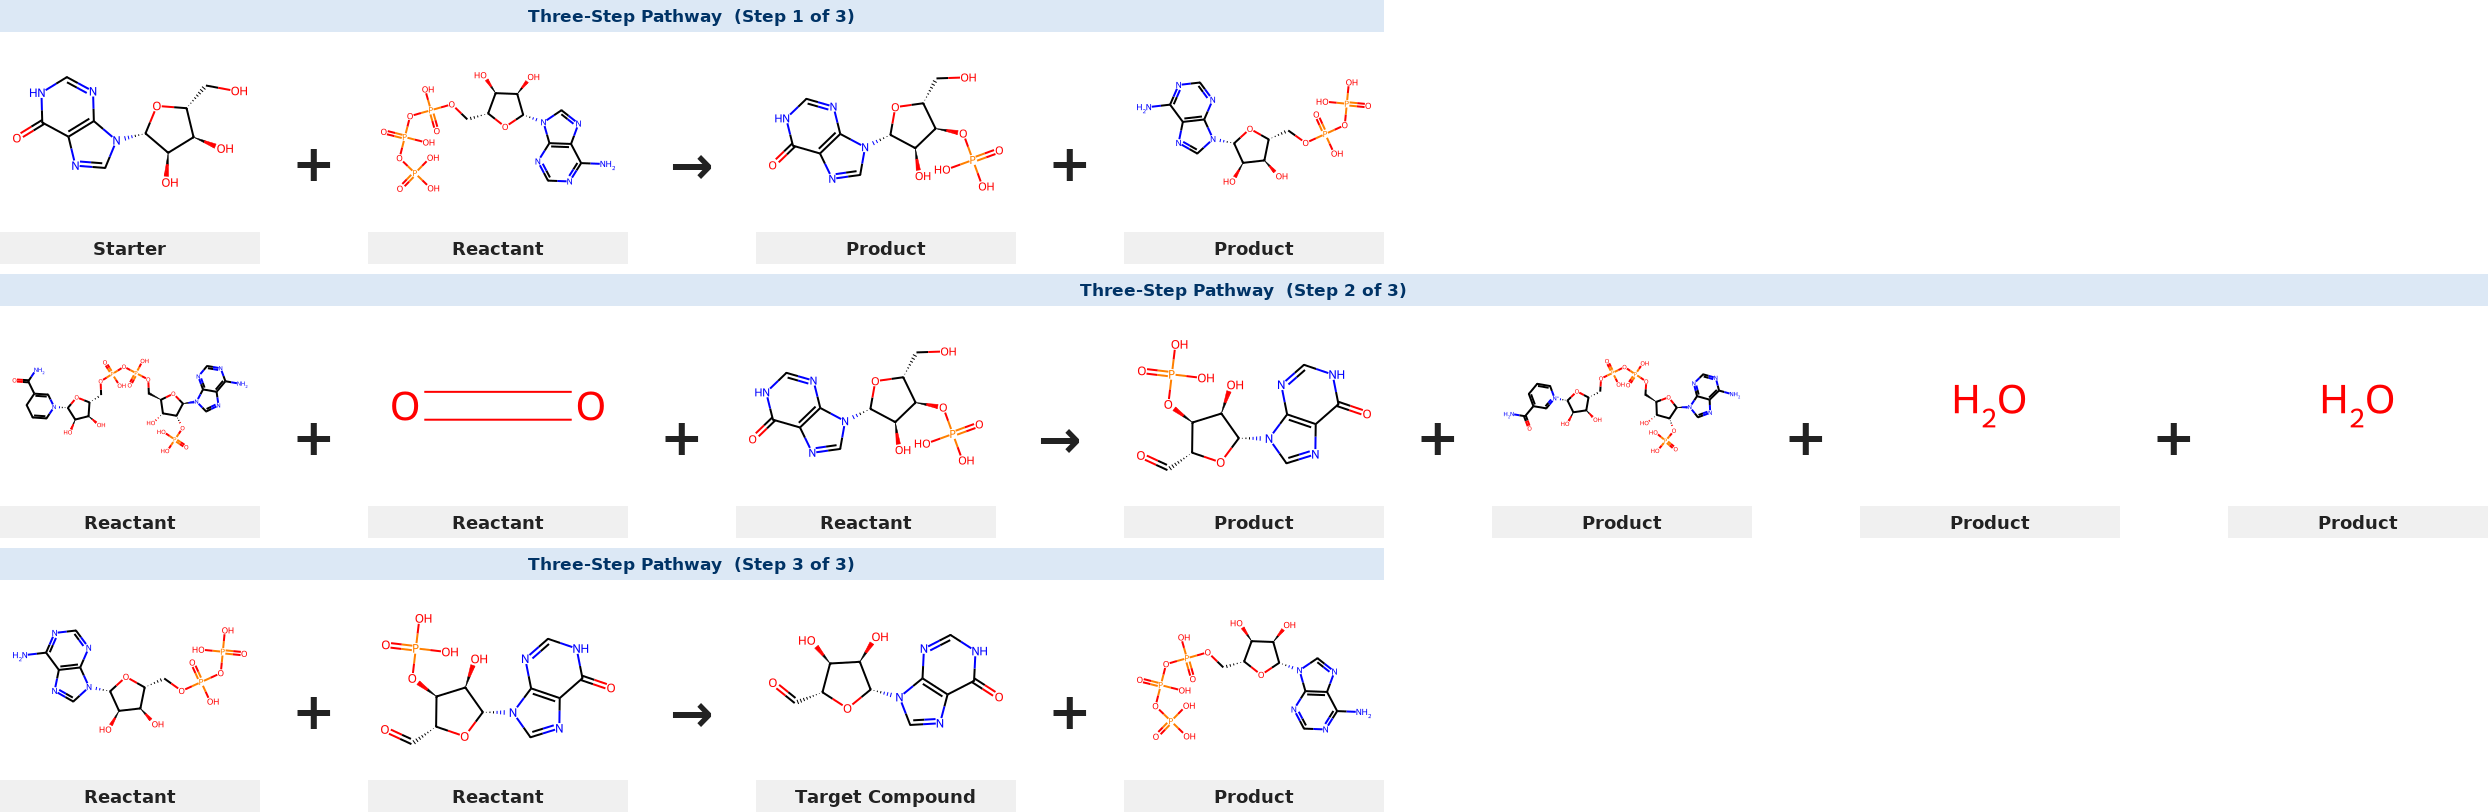


Total pathway figures saved: 9


In [19]:
molSize      = (260, 200)
sepWidth     = 80
stepBannerH  = 32
stepGap      = 10
depthWords   = {1: "One-Step", 2: "Two-Step", 3: "Three-Step"}


def loadFont(size):
    for path in [
        "/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf",
        "/usr/share/fonts/truetype/liberation/LiberationSans-Bold.ttf",
        "/usr/share/fonts/truetype/freefont/FreeSansBold.ttf",
    ]:
        try:
            return ImageFont.truetype(path, size)
        except Exception:
            continue
    return ImageFont.load_default()

fontSep   = loadFont(52)
fontLabel = loadFont(18)
fontStep  = loadFont(17)


def rdkitImageToPil(imageObj):
    if isinstance(imageObj, Image.Image):
        return imageObj.convert("RGB")
    if isinstance(imageObj, (bytes, bytearray)):
        return Image.open(BytesIO(imageObj)).convert("RGB")
    return Image.open(BytesIO(imageObj.data)).convert("RGB")


def centeredText(draw, text, imgWidth, y, font, color="black"):
    try:
        bb    = draw.textbbox((0, 0), text, font=font)
        textW = bb[2] - bb[0]
    except Exception:
        textW = len(text) * 8
    draw.text(((imgWidth - textW) // 2, y), text, fill=color, font=font)


def getMolLabel(canon, canonStarterSet, genuineProductSet, isLastStep, isProductSide):
    if not isProductSide:
        return "Starter" if canon in canonStarterSet else "Reactant"
    if isProductSide and canon in genuineProductSet and isLastStep:
        return "Target Compound"
    return "Product"


def makeLabeledMolImage(smi, label):
    mol = Chem.MolFromSmiles(str(smi))
    if mol is None:
        return None
    molImg = rdkitImageToPil(Draw.MolToImage(mol, size=molSize))
    banner = Image.new("RGB", (molImg.width, 32), "#f0f0f0")
    centeredText(ImageDraw.Draw(banner), label, molImg.width, 6, fontLabel, "#222222")
    out = Image.new("RGB", (molImg.width, molImg.height + banner.height), "white")
    out.paste(molImg, (0, 0))
    out.paste(banner, (0, molImg.height))
    return out


def makeSeparatorImage(text, height, width=80):
    img  = Image.new("RGB", (width, height), "white")
    draw = ImageDraw.Draw(img)
    try:
        bb     = draw.textbbox((0, 0), text, font=fontSep)
        tw, th = bb[2] - bb[0], bb[3] - bb[1]
    except Exception:
        tw, th = 30, 50
    draw.text(((width - tw) // 2, (height - th) // 2), text, fill="#222222", font=fontSep)
    return img


def renderReactionStep(rxnIdx, reactionDF, canonStarterSet, genuineProductSet,
                       canonHelperSet, isLastStep, stepLabel):
    row = reactionDF.loc[rxnIdx]

    reactantSmis = splitMoleculeString(row["reactants"])
    productSmis  = splitMoleculeString(row["products"])

    reactantSmis = (
        [s for s in reactantSmis if canonSmiles(s) in canonStarterSet] +
        [s for s in reactantSmis if canonSmiles(s) not in canonStarterSet]
    )
    productSmis = (
        [s for s in productSmis if canonSmiles(s) in genuineProductSet] +
        [s for s in productSmis if canonSmiles(s) not in genuineProductSet]
    )

    reactantImgs = [
        img for img in [
            makeLabeledMolImage(
                s,
                getMolLabel(canonSmiles(s), canonStarterSet, genuineProductSet,
                            isLastStep, isProductSide=False),
            ) for s in reactantSmis
        ] if img is not None
    ]
    productImgs = [
        img for img in [
            makeLabeledMolImage(
                s,
                getMolLabel(canonSmiles(s), canonStarterSet, genuineProductSet,
                            isLastStep, isProductSide=True),
            ) for s in productSmis
        ] if img is not None
    ]

    if not reactantImgs or not productImgs:
        return None

    maxH  = max(img.height for img in reactantImgs + productImgs)
    gap   = 14
    parts = []
    for i, img in enumerate(reactantImgs):
        parts.append(img)
        if i < len(reactantImgs) - 1:
            parts.append(makeSeparatorImage("+", maxH, width=sepWidth))
    parts.append(makeSeparatorImage("→", maxH, width=100))
    for i, img in enumerate(productImgs):
        parts.append(img)
        if i < len(productImgs) - 1:
            parts.append(makeSeparatorImage("+", maxH, width=sepWidth))

    totalW = sum(p.width for p in parts) + gap * (len(parts) - 1)
    rxnRow = Image.new("RGB", (totalW, maxH), "white")
    x      = 0
    for part in parts:
        rxnRow.paste(part, (x, (maxH - part.height) // 2))
        x += part.width + gap

    stepBanner = Image.new("RGB", (totalW, stepBannerH), "#dce8f5")
    centeredText(ImageDraw.Draw(stepBanner), stepLabel, totalW,
                 (stepBannerH - 20) // 2, fontStep, "#003366")

    panel = Image.new("RGB", (totalW, stepBannerH + rxnRow.height), "white")
    panel.paste(stepBanner, (0, 0))
    panel.paste(rxnRow,     (0, stepBannerH))
    return panel


def stackStepPanels(panels):
    if not panels:
        return None
    w      = max(p.width for p in panels)
    totalH = sum(p.height for p in panels) + stepGap * (len(panels) - 1)
    canvas = Image.new("RGB", (w, totalH), "white")
    y = 0
    for p in panels:
        canvas.paste(p, (0, y))
        y += p.height + stepGap
    return canvas


def findPathwayChains(reactionDF, canonStarterSet, genuineProductSet,
                      canonHelperSet, maxDepth=3, maxPerDepth=3):
    """
    Exhaustive BFS with no frontier cap. Safe because DORAnet ran a bounded
    3-step expansion, so the reaction network is finite and the BFS is
    guaranteed to terminate.
    """
    molToRxnIdxs = defaultdict(list)
    for idx, row in reactionDF.iterrows():
        for smi in splitMoleculeString(row["reactants"]):
            c = canonSmiles(smi)
            if c not in canonHelperSet:
                molToRxnIdxs[c].append(idx)

    def getNonHelperProducts(rxnIdx):
        row = reactionDF.loc[rxnIdx]
        return frozenset(
            canonSmiles(s) for s in splitMoleculeString(row["products"])
            if canonSmiles(s) not in canonHelperSet
        )

    pathways = {d: [] for d in range(1, maxDepth + 1)}
    queue    = deque()

    for starterCanon in canonStarterSet:
        for rxnIdx in molToRxnIdxs.get(starterCanon, []):
            products = getNonHelperProducts(rxnIdx)
            chain    = (rxnIdx,)
            if products & genuineProductSet and len(pathways[1]) < maxPerDepth:
                pathways[1].append(chain)
            if maxDepth > 1:
                queue.append((chain, products, frozenset({rxnIdx})))

    while queue:
        chain, availMols, visitedRxns = queue.popleft()
        depth = len(chain)

        if depth >= maxDepth:
            continue

        if all(len(pathways[d]) >= maxPerDepth for d in range(depth + 1, maxDepth + 1)):
            continue

        for mol in availMols:
            for rxnIdx in molToRxnIdxs.get(mol, []):
                if rxnIdx in visitedRxns:
                    continue

                products  = getNonHelperProducts(rxnIdx)
                newChain  = chain + (rxnIdx,)
                newDepth  = len(newChain)

                if products & genuineProductSet and len(pathways[newDepth]) < maxPerDepth:
                    pathways[newDepth].append(newChain)

                if newDepth < maxDepth:
                    queue.append((newChain, products, visitedRxns | {rxnIdx}))

    return pathways


genuineProductSet = set(generatedCompoundsDF["Canonical_SMILES"].dropna().unique())

print("Searching for 1-step, 2-step, and 3-step pathway chains...")
pathwaysByDepth = findPathwayChains(
    reactionDF,
    canonStarterSet,
    genuineProductSet,
    canonHelperSet,
)
for d, chains in pathwaysByDepth.items():
    print(f"  {d}-step pathways found: {len(chains)}")

savedFiles = []

for depth in range(1, 4):
    chains = pathwaysByDepth[depth]
    if not chains:
        print(f"\nNo {depth}-step pathways found.")
        continue

    for pIdx, chain in enumerate(chains):
        stepPanels = []
        totalSteps = len(chain)

        for stepIdx, rxnIdx in enumerate(chain):
            isLastStep = (stepIdx == totalSteps - 1)
            stepLabel  = (
                f"{depthWords[totalSteps]} Pathway  "
                f"(Step {stepIdx + 1} of {totalSteps})"
            )
            panel = renderReactionStep(
                rxnIdx, reactionDF, canonStarterSet, genuineProductSet,
                canonHelperSet, isLastStep, stepLabel,
            )
            if panel is not None:
                stepPanels.append(panel)

        pathwayImg = stackStepPanels(stepPanels)
        if pathwayImg is None:
            continue

        baseName = f"{fileNamePrefix}_step{depth}_pathway{pIdx + 1}"
        pngPath  = f"{baseName}.png"
        pdfPath  = f"{baseName}.pdf"

        pathwayImg.save(pngPath, format="PNG", dpi=(600, 600))
        pathwayImg.save(pdfPath, format="PDF", resolution=600)
        savedFiles.append((pngPath, pdfPath))

        print(f"Saved: {pngPath}  |  {pdfPath}")
        display(pathwayImg)

print(f"\nTotal pathway figures saved: {len(savedFiles)}")